In [69]:

import torch
import torchvision
import matplotlib.pyplot as plt
import torch.nn as nn

In [67]:
transform = torchvision.transforms.Compose(
    [
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Normalize((0.1307,), (0.3081,)),
    ]
)
data = torchvision.datasets.MNIST(
    root="data", train=True, download=True, transform=transform
)
data[0][0].shape

torch.Size([1, 28, 28])

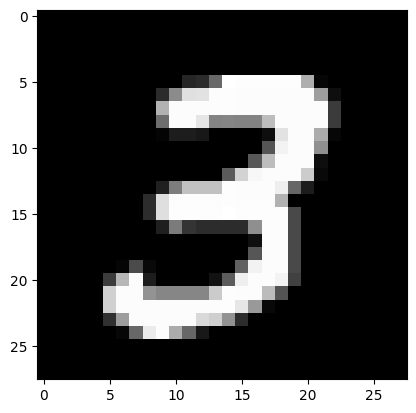

In [ ]:
image, label = data[7]
plt.imshow(image.squeeze(), cmap="gray")

In [68]:
train_loader = torch.utils.data.DataLoader(data, batch_size=64, shuffle=True)

train_loader

for i, j in train_loader:
    print(i.shape)
    print(j.shape)
    break

torch.Size([64, 1, 28, 28])
torch.Size([64])


In [70]:
class SimpleNet(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.fc1 = nn.Linear(784,128)
        self.fc2 = nn.Linear(128,64)
        self.fc3 = nn.Linear(64,10)
    
    def forward(self, x):
        x = x.view(x.size(0), 784) 
        x = nn.functional.relu(self.fc1(x))
        x = nn.functional.relu(self.fc2(x))
        return self.fc3(x)


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = SimpleNet().to('cuda')
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.01
)
device

'cuda'

In [73]:
for epoch in range(10):
    pred = model.train()
    lossno = 0
    for images, labels in train_loader:
        model.zero_grad()
        images = images.to(device)
        labels = labels.to(device)

        output = model(images)
        loss = criterion(output, labels)
        loss.backward()
        optimizer.step()
        
        lossno += loss.item()
        
    print(
        f"Epoch {epoch+1}, Loss: {lossno:.4f}"
    )
        
        
        

Epoch 1, Loss: 261.2867
Epoch 2, Loss: 178.5649
Epoch 3, Loss: 160.3589
Epoch 4, Loss: 141.7394
Epoch 5, Loss: 136.6824
Epoch 6, Loss: 130.9813
Epoch 7, Loss: 129.7779
Epoch 8, Loss: 118.2501
Epoch 9, Loss: 119.2063
Epoch 10, Loss: 102.3513


In [78]:
test_dataset = torchvision.datasets.MNIST(
    root="data", train=False, download=True, transform=transform
)
test_loader = torch.utils.data.DataLoader(data, batch_size=64, shuffle=True)

In [79]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(
            outputs,
            1
        )

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()

accuracy = 100 * correct / total

print(
    f"Accuracy: {accuracy:.2f}%"
)

Accuracy: 97.84%
